# Kaggle API Setup and Dataset Download

In [2]:
print("Please upload your kaggle.json file!")
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\nDownloading the Brain MRI dataset (Small Version)...")
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection

print("Unzipping dataset...")
!unzip -q brain-mri-images-for-brain-tumor-detection.zip


Please upload your kaggle.json file!


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
brain-mri-images-for-brain-tumor-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping dataset...


# Create Training, Validation, and Test Datasets

In [3]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'brain_tumor_dataset',
    validation_split=0.2,
    #holding back 20% of the images
    subset="training",
    seed=123,
    #this ensures randomness
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    'brain_tumor_dataset',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)
test_dataset = validation_dataset.take(1)
validation_dataset = validation_dataset.skip(1)
#doesn't include the batch we took for training the AI Model

class_names = train_dataset.class_names
print("\nFound the following classes:", class_names)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.

Found the following classes: ['no', 'yes']


# Build CNN Model with Data Augmentation

In [5]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential(
  [
    #augmentation: Rotate/zoom in/zoom out/etc. images to evaluate the image in completely different ways
    #one image can be rotated and have four different unique images
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

  ]
)

model = models.Sequential([
    #building a model using a sequential AVI: this is going to augment the data
  layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
    #feature detectors (analyze edge cases)
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
    #outputs a 2D grid
  layers.Dense(128, activation='relu'),
    #makes decision/prediction based on previous information
  layers.Dropout(0.5),
    #tends to overfit: the model is very used to training data so it won't perform as well
    #makes sure its not memorizing from the training data
  layers.Dense(1, activation='sigmoid')
    #this layers outputs the data
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
#adam optimizer is standard: controls learning rates
#loss is standard for binary data set
#different types of metrics: varies depending on the task

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,369 (24.59 MB)

 Trainable params: 6,446,369 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

# Train, Visualize, and Evaluate Model

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8346 - loss: 0.3917 - val_accuracy: 0.8889 - val_loss: 0.4031
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8013 - loss: 0.4231 - val_accuracy: 0.8333 - val_loss: 0.4123
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7402 - loss: 0.5450 - val_accuracy: 0.8889 - val_loss: 0.4584
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8229 - loss: 0.3973 - val_accuracy: 0.9444 - val_loss: 0.2484
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7920 - loss: 0.4227 - val_accuracy: 0.8333 - val_loss: 0.3140
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8100 - loss: 0.4390 - val_accuracy: 0.7778 - val_loss: 0.5890
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7642 - loss: 0.4664 - val_accuracy: 0.9444 - val_loss: 0.3572
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8464 - loss: 0.4370 - val_accuracy: 0.8889 - val_loss: 0.2957
Epoch 9/

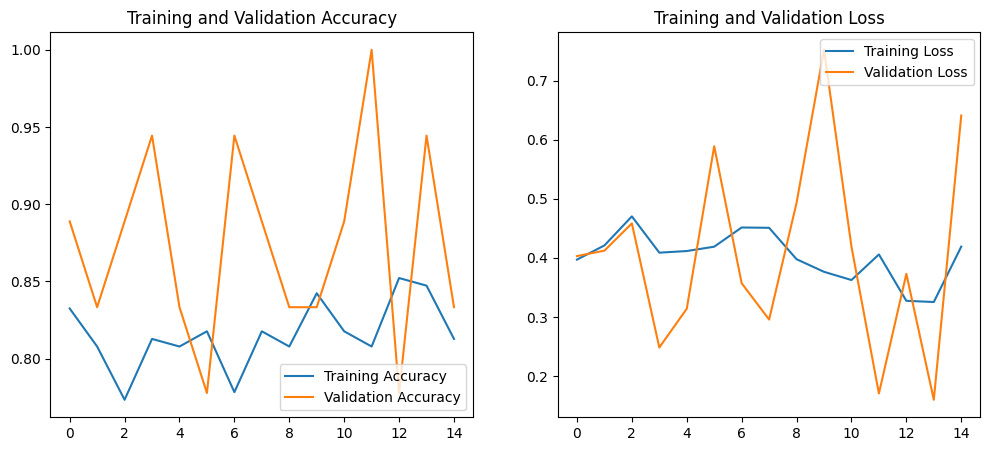


Evaluating model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8750 - loss: 0.4107

 Test Accuracy: 87.50%


In [7]:
epochs = 15
#epoch is a full pass-through of the training data
#should run it a lot but not too many so it doesn't memorize the data
history = model.fit(
  train_dataset,
  validation_data=validation_dataset,
  epochs=epochs
)

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

print("\nEvaluating model on the test set...")
loss, accuracy = model.evaluate(test_dataset)
print(f"\n Test Accuracy: {accuracy*100:.2f}%")

# Visualize Predictions

Evaluating model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step - accuracy: 0.8750 - loss: 0.3879

Test Accuracy: 87.50%
------------------------------
The model prediction if there is a tumor yes or no:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step


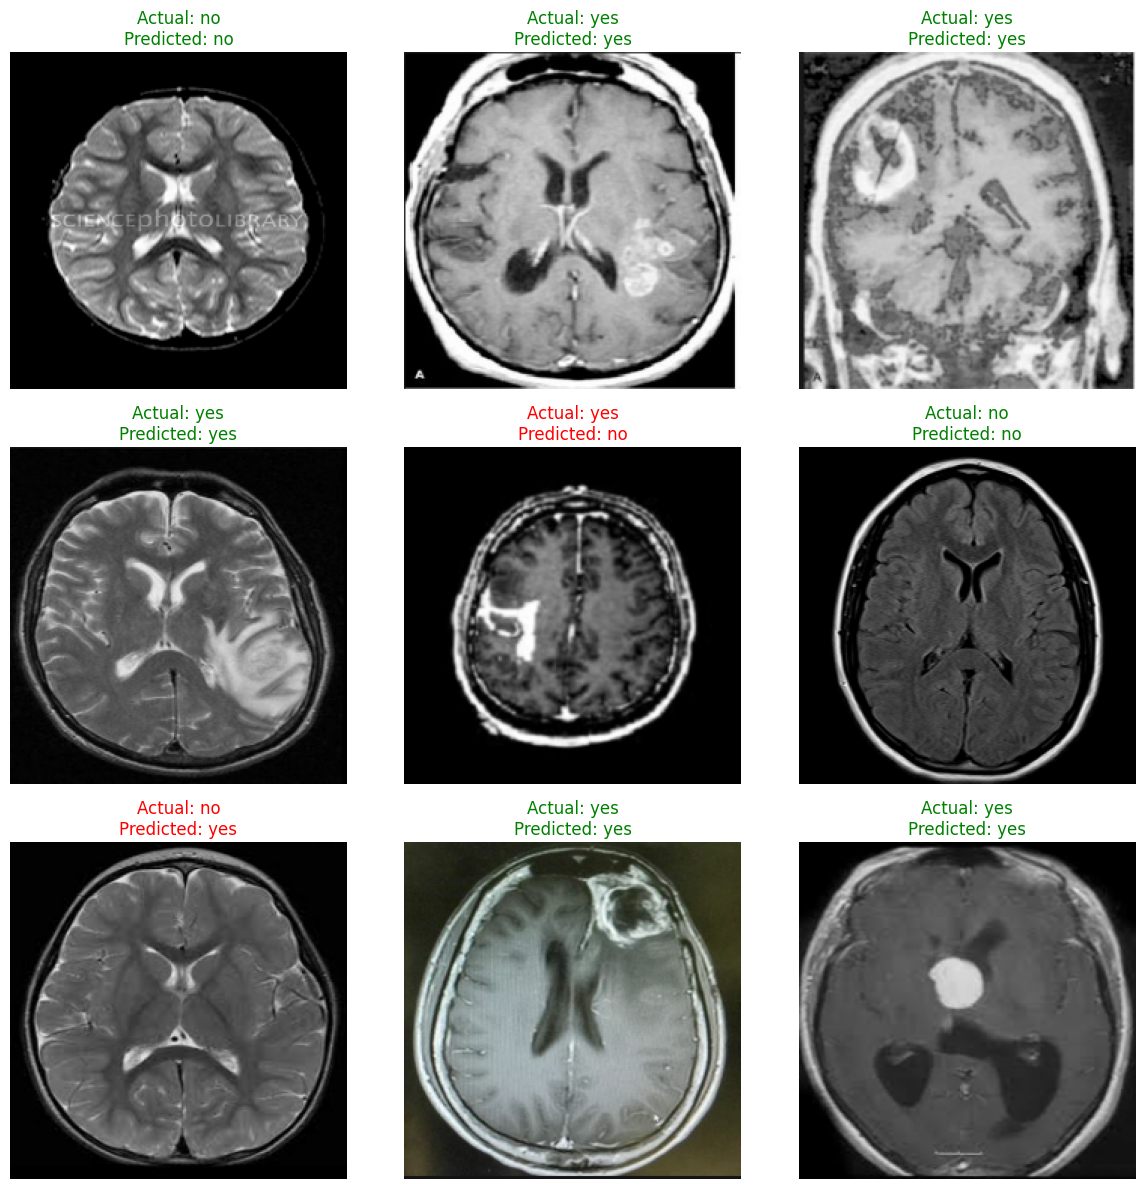

In [8]:
print("Evaluating model on the test set...")
loss, accuracy = model.evaluate(test_dataset)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print("-" * 30)

print("The model prediction if there is a tumor yes or no:")

plt.figure(figsize=(12, 12))

for images, labels in test_dataset.take(1):
  predictions = model.predict(images)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class_index = 1 if predictions[i] > 0.5 else 0
    predicted_class_name = class_names[predicted_class_index]
    actual_class_name = class_names[int(labels[i])]

    title_color = 'green' if predicted_class_name == actual_class_name else 'red'

    plt.title(f"Actual: {actual_class_name}\nPredicted: {predicted_class_name}", color=title_color)
    plt.axis("off")

plt.tight_layout()
plt.show()